# DEMI | NOVA FCT

## Fatigue Design of Mechanical Joints and Aerospace Structures

##### José Xavier & Rui Martins

### Problems 6 — Crack growth applications

- [Exercise 6.1](#ex1) — Effect of $R$-ratio on fatigue life
- [Exercise 6.2](#ex2) — Effect of initial crack size $a_0$
- [Exercise 6.3](#ex3) — SEN-3PB specimen: $\Delta P$–$N_f$ curve
- [Exercise 6.4](#ex4) — Accuracy considerations for crack growth predictions
- [Exercise 6.5](#ex5) — Variable-amplitude interaction effects


In [1]:
import numpy as np
import matplotlib.pyplot as plt

FS = 14

# Reset to default style so any IDE dark-theme overrides do not bleed in.
plt.style.use('default')

plt.rcParams.update({
    'figure.figsize':   (10, 4.2), 'figure.dpi': 110,
    'font.family':      'serif',  'font.size': FS,
    'axes.grid':        True,     'grid.alpha': 0.30,
    'lines.linewidth':  2,
    # --- Backgrounds (white) ---
    'axes.facecolor':   'white',
    'figure.facecolor': 'white',
    'savefig.facecolor':'white',
    'legend.facecolor': 'white',
    'legend.edgecolor': 'black',
    # --- Force all text BLACK so the IDE dark theme does not hide it ---
    'text.color':       'black',
    'axes.labelcolor':  'black',
    'axes.edgecolor':   'black',
    'axes.titlecolor':  'black',
    'xtick.color':      'black',
    'ytick.color':      'black',
    'xtick.labelcolor': 'black',
    'ytick.labelcolor': 'black',
    'legend.labelcolor':'black',
})
COLORS = dict(curve='#1f4e79', point='#c0392b', accent='#8e44ad',
              guide='0.55', warn='#e67e22', cool='#16a085', soft='#2980b9')

SQRT1000 = np.sqrt(1000.0)

# ---------- shape functions ----------
def Y_feddersen_DK(aW):
    aw = np.asarray(aW, dtype=float)
    return (1 - 0.1*aw**2 + 0.96*aw**4)*np.sqrt(1.0/np.cos(np.pi*aw))

def f_SEN3PB(aW):
    aw = np.asarray(aW, dtype=float)
    num = 3.0*np.sqrt(aw)
    den = 2.0*(1.0 + 2.0*aw)*(1.0 - aw)**1.5
    bracket = 1.99 - aw*(1.0 - aw)*(2.15 - 3.93*aw + 2.7*aw**2)
    return (num/den)*bracket

# ---------- Paris integrator (CCT panel, mm/N units) ----------
def integrate_CCT(a0_mm, W_mm, dsigma, R, C, m, K_IC_MPa_sqrt_m, da_step=0.1):
    '''Returns (a_arr, N_arr, a_c). da/dN in mm/cycle, ΔK in N·mm^(-3/2).'''
    sigma_max = dsigma/(1-R)
    K_IC_Nmm  = K_IC_MPa_sqrt_m*SQRT1000

    # Critical a_c by bisection
    def K_max(a):
        return float(Y_feddersen_DK(a/W_mm))*sigma_max*np.sqrt(np.pi*a)
    lo, hi = a0_mm, 0.499*W_mm
    for _ in range(80):
        mid = 0.5*(lo+hi)
        if K_max(mid) < K_IC_Nmm: lo = mid
        else:                     hi = mid
    a_c = 0.5*(lo+hi)

    # Forward Euler
    a, N = a0_mm, 0.0
    a_list, N_list = [a], [N]
    while a < a_c:
        Y = float(Y_feddersen_DK(a/W_mm))
        dK = Y*dsigma*np.sqrt(np.pi*a)            # N·mm^-1.5
        dadN = C*dK**m
        step = min(da_step, a_c - a)
        N += step/dadN
        a += step
        a_list.append(a); N_list.append(N)
    return np.array(a_list), np.array(N_list), a_c


---

## Formulary

The integrator used in this notebook implements the Paris law
$\mathrm{d}a/\mathrm{d}N = C\,(\Delta K)^{m}$ with the refined Feddersen
correction for a CCT panel (Problem 4 formulary). $a_{c}$ is found numerically
by solving $K_{\max}(a_{c})=K_{IC}$. Units: mm/cycle for $\mathrm{d}a/\mathrm{d}N$
and N·mm⁻³ᐟ² for $\Delta K$.


<a id='ex1'></a>
---

## Exercise 6.1 — Effect of $R$-ratio on fatigue life

Using the CCT panel from Exercise 4.4 (Week 4), with $\Delta\sigma = 200$ MPa, $W = 100$ mm, $2a_0 = 1$ mm:

(a) Compute the fatigue life $N_f$ for $R = 0,  0.1,  0.25,  0.5$. Note that $\sigma_{\max} = \Delta\sigma/(1 - R)$ changes with $R$, which affects $a_c$.

(b) Plot all four $a(N)$ curves on the same graph.

(c) Discuss the trend: why does increasing $R$ (for the same $\Delta\sigma$) reduce $N_f$?

### Solution

(a) and (b)


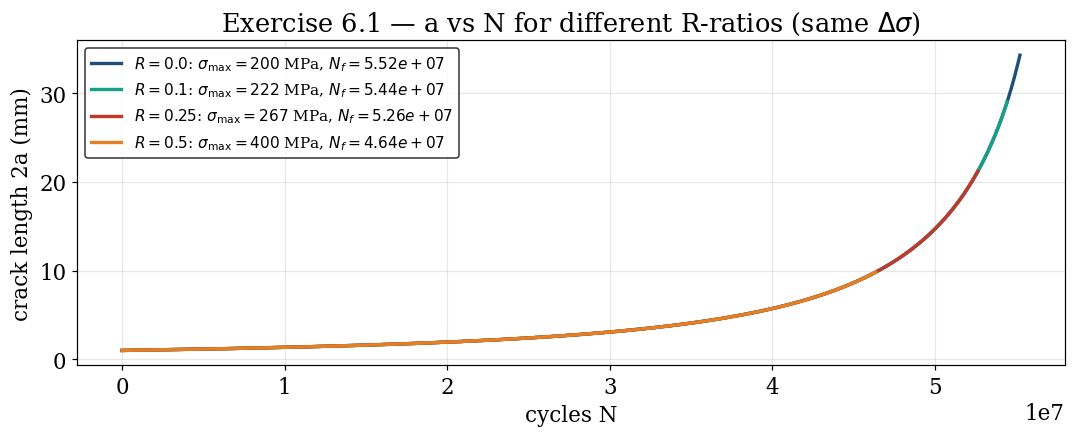


    R   σ_max (MPa)   a_c (mm)          N_f
 0.00        200.00      17.15    5.523e+07
 0.10        222.22      14.52    5.445e+07
 0.25        266.67      10.60    5.264e+07
 0.50        400.00       4.92    4.636e+07


In [2]:
W, a0, dsigma, K_IC = 100.0, 0.5, 200.0, 50.0
C, m = 1e-15, 3.0
R_list = [0.0, 0.1, 0.25, 0.50]

fig, ax = plt.subplots()
results = []
for Ri, col in zip(R_list, [COLORS['curve'], COLORS['cool'], COLORS['point'], COLORS['warn']]):
    a_arr, N_arr, a_c = integrate_CCT(a0, W, dsigma, Ri, C, m, K_IC, da_step=0.1)
    Nf = N_arr[-1]
    ax.plot(N_arr, 2*a_arr, color=col, lw=2.2,
            label=fr'$R={Ri}$: $\sigma_{{\max}}={dsigma/(1-Ri):.0f}$ MPa, $N_f={Nf:.2e}$')
    results.append((Ri, a_c, Nf))
ax.set_xlabel('cycles N'); ax.set_ylabel('crack length 2a (mm)')
ax.set_title('Exercise 6.1 — a vs N for different R-ratios (same $\\Delta\\sigma$)')
ax.legend(fontsize=10); plt.tight_layout(); plt.show()

print(f'\n{"R":>5} {"σ_max (MPa)":>13} {"a_c (mm)":>10} {"N_f":>12}')
for Ri, a_c, Nf in results:
    print(f'{Ri:5.2f} {dsigma/(1-Ri):13.2f} {a_c:10.2f} {Nf:12.3e}')


#### (c) Why does increasing $R$ shorten $N_{f}$ here?

In this exercise $\Delta K$ depends *only* on $\Delta\sigma$, not on $R$ —
so the propagation rate $\mathrm{d}a/\mathrm{d}N$ is *unchanged*. What
changes with $R$ is $\sigma_{\max}=\Delta\sigma/(1-R)$ and hence
$K_{\max}$, which sets the **critical crack length** $a_{c}$. Higher $R$ →
higher $\sigma_{\max}$ → smaller $a_{c}$ → less remaining ligament to
propagate through → shorter life.

In reality there is a *second* effect via crack-closure: low $R$ has higher
closure (lower $\Delta K_{\text{eff}}$) and slower crack growth; high $R$
opens the crack throughout the cycle. Both effects reinforce: increasing $R$
*generally* shortens the life.


#### Solution summary — Exercise 6.1

| $R$ | $\sigma_{\max}$ (MPa) | $a_c$ (mm) | $N_f$ (cycles) |
|---:|---:|---:|---:|
| 0.00 | 200 | 17.15 | $5.52 \times 10^7$ |
| 0.10 | 222 | 14.52 | $5.45 \times 10^7$ |
| 0.25 | 267 | 10.60 | $5.26 \times 10^7$ |
| 0.50 | 400 |  4.92 | $4.64 \times 10^7$ |

Increasing $R$ at fixed $\Delta\sigma$ raises $\sigma_{\max}$, reducing $a_c$ (shorter critical ligament) and therefore $N_f$.

<a id='ex2'></a>
---

## Exercise 6.2 — Effect of initial crack size $a_0$

**Effect of initial crack size**

Using the same panel and $R = 0.25$:

(a) Compute $N_f$ for $2a_0 = 0.5,  1.0,  2.0,  5.0$ mm.

(b) Plot $N_f$ vs. $a_0$ on a semi-log scale.

(c) Discuss the sensitivity of fatigue life to the initial defect size and its implications for non-destructive inspection.



 2a_0 (mm)            N_f
      0.50      8.547e+07
      1.00      5.264e+07
      2.00      3.187e+07
      5.00      1.454e+07


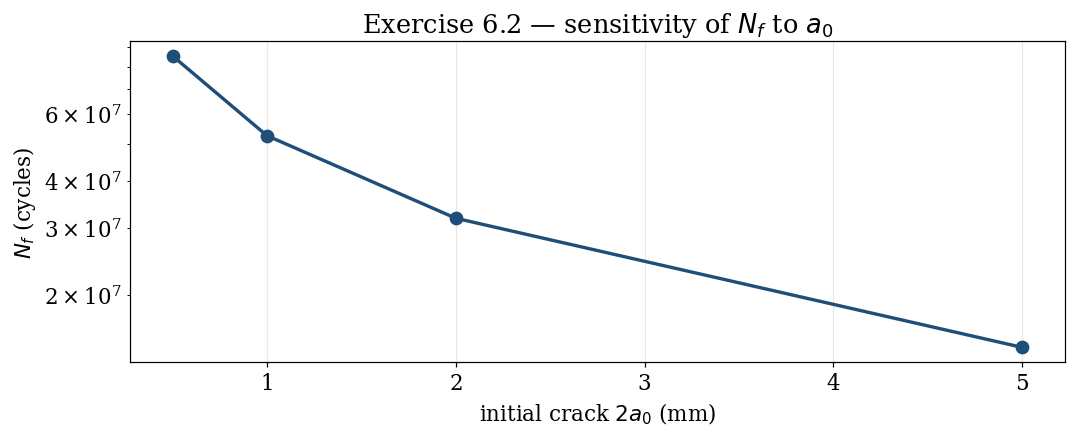

In [3]:
R0 = 0.25
a0_list_mm = np.array([0.5, 1.0, 2.0, 5.0])/2   # half-lengths corresponding to 2a_0 = ...

Nf_list = []
for a0_i in a0_list_mm:
    _, N_arr, _ = integrate_CCT(a0_i, W, dsigma, R0, C, m, K_IC, da_step=0.1)
    Nf_list.append(N_arr[-1])
Nf_list = np.array(Nf_list)

print(f'{"2a_0 (mm)":>10} {"N_f":>14}')
for a0_i, Nf in zip(2*a0_list_mm, Nf_list):
    print(f'{a0_i:10.2f} {Nf:14.3e}')

fig, ax = plt.subplots()
ax.semilogy(2*a0_list_mm, Nf_list, 'o-', color=COLORS['curve'], lw=2.2, markersize=8)
ax.set_xlabel(r'initial crack $2a_0$ (mm)')
ax.set_ylabel(r'$N_f$ (cycles)')
ax.set_title('Exercise 6.2 — sensitivity of $N_f$ to $a_0$')
plt.tight_layout(); plt.show()


#### Discussion

Because the integral $\int a^{-m/2}\,\mathrm{d}a$ is dominated by the
*lower* limit when $m>2$, a small change in $a_{0}$ produces a *large* change
in $N_{f}$. Halving $a_{0}$ (from 1 mm to 0.5 mm) roughly **doubles** the
life. This is the central message for **non-destructive inspection**: an NDI
threshold sets the assumed $a_{0}$ for life prediction, and improving
detection sensitivity translates directly into longer certified life.


#### Solution summary — Exercise 6.2

| $2a_0$ (mm) | $N_f$ (cycles) |
|---:|---:|
| 0.50 | $8.55 \times 10^7$ |
| 1.00 | $5.26 \times 10^7$ |
| 2.00 | $3.19 \times 10^7$ |
| 5.00 | $1.45 \times 10^7$ |

Halving $2a_0$ from 1 mm to 0.5 mm increases $N_f$ by $\approx 63\%$; the sensitivity is strong because the Paris integral $\int a^{-m/2}\,\mathrm{d}a$ is dominated by the lower limit when $m > 2$. This underpins the damage-tolerance philosophy: a smaller NDI detection threshold translates directly into a longer certified life.

<a id='ex3'></a>
---

## Exercise 6.3 — SEN-3PB specimen: $\Delta P$–$N_f$ curve

SEN-3PB: $B=10$ mm, $W=30$ mm, $S=150$ mm, $a_{0}=0.25$ mm, $K_{IC}=50$ MPa√m,
$R=0.3$, same Paris law as Ex 4.4.

Consider a SEN-3PB specimen with $B = 10$ mm, $W = 30$ mm, $S = 150$ mm, initial crack $a_0 = 0.25$ mm, and $K_{IC} = 50 \text{MPa}\sqrt{\text{m}}$. The material follows the same Paris law as Exercise 4.4. $R = 0.3$.

(a) For applied load ranges $\Delta P = 0.5,  1.0,  1.5,  2.0,  2.5$ kN, compute $N_f$ by Paris integration using the SEN-3PB shape function.

(b) Plot the $\Delta P$--$N_f$ curve on a log--log scale. Compare with a straight line (power law): does the SEN-3PB geometry produce a linear $\Delta P$--$N_f$ relationship?

### Solution


ΔP = 0.5 kN  →  a_c = 26.484 mm,  N_f = 2.782e+11
ΔP = 1.0 kN  →  a_c = 24.441 mm,  N_f = 3.478e+10
ΔP = 1.5 kN  →  a_c = 22.731 mm,  N_f = 1.030e+10
ΔP = 2.0 kN  →  a_c = 21.209 mm,  N_f = 4.346e+09
ΔP = 2.5 kN  →  a_c = 19.818 mm,  N_f = 2.224e+09

Log-log slope of ΔP vs N_f : -3.000
(For pure Paris with constant Y, the slope would be exactly −m = −3.)


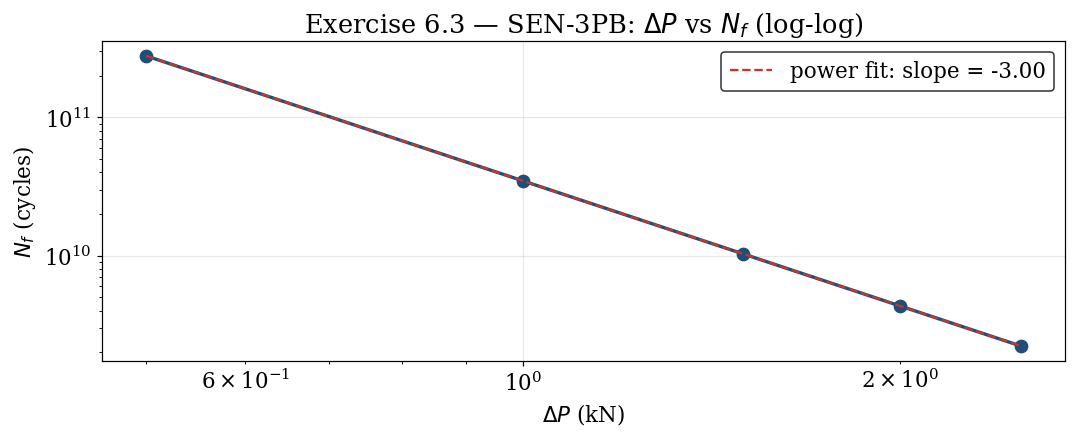

In [4]:
B, W3, S = 10.0, 30.0, 150.0
a0_3, K_IC = 0.25, 50.0
R3 = 0.3
C, m = 1e-15, 3.0
K_IC_Nmm = K_IC*SQRT1000

def K_max_SEN3PB(a, dP, R):
    P_max = dP/(1-R)
    aw    = a/W3
    return (P_max*S)/(B*W3**1.5)*float(f_SEN3PB(aw))

def integrate_SEN3PB(dP, R, da=0.05):
    # critical a
    lo, hi = a0_3, 0.95*W3
    for _ in range(80):
        mid = 0.5*(lo+hi)
        if K_max_SEN3PB(mid, dP, R) < K_IC_Nmm: lo = mid
        else:                                    hi = mid
    a_c = 0.5*(lo+hi)
    a, N = a0_3, 0.0
    while a < a_c:
        aw = a/W3
        dK = (dP*S)/(B*W3**1.5)*float(f_SEN3PB(aw))         # N·mm^-1.5
        dadN = C*dK**m
        step = min(da, a_c - a)
        N += step/dadN
        a += step
    return a_c, N

dP_arr_kN = np.array([0.5, 1.0, 1.5, 2.0, 2.5])
results = []
for dP_kN in dP_arr_kN:
    a_c, Nf = integrate_SEN3PB(dP_kN*1e3, R3)
    results.append((dP_kN, a_c, Nf))
    print(f'ΔP = {dP_kN:.1f} kN  →  a_c = {a_c:.3f} mm,  N_f = {Nf:.3e}')

dP = np.array([r[0] for r in results])
Nf = np.array([r[2] for r in results])
slope, intercept = np.polyfit(np.log(dP), np.log(Nf), 1)
print(f'\nLog-log slope of ΔP vs N_f : {slope:.3f}')
print('(For pure Paris with constant Y, the slope would be exactly −m = −3.)')

fig, ax = plt.subplots()
ax.loglog(dP, Nf, 'o-', color=COLORS['curve'], lw=2.2, markersize=8)
# fit line
Nf_fit = np.exp(intercept + slope*np.log(dP))
ax.loglog(dP, Nf_fit, '--', color=COLORS['point'], lw=1.5,
          label=fr'power fit: slope = {slope:.2f}')
ax.set_xlabel(r'$\Delta P$ (kN)'); ax.set_ylabel(r'$N_f$ (cycles)')
ax.set_title('Exercise 6.3 — SEN-3PB: $\\Delta P$ vs $N_f$ (log-log)')
ax.legend(); plt.tight_layout(); plt.show()


#### Comment

For SEN-3PB the shape function $f(a/W)$ varies with $a/W$ and $a_c$ decreases
as $\Delta P$ rises. Nevertheless, the computed log–log slope ($\approx -3.0 = -m$)
shows that $N_f \propto \Delta P^{-m}$ holds well over this load range — the life
is dominated by early propagation where $f(a/W)$ is still nearly constant.
Over a wider load range or for a longer crack, deviations from a pure power law
become more pronounced.

#### Solution summary — Exercise 6.3

| $\Delta P$ (kN) | $a_c$ (mm) | $N_f$ (cycles) |
|---:|---:|---:|
| 0.5 | 26.48 | $2.78 \times 10^{11}$ |
| 1.0 | 24.44 | $3.48 \times 10^{10}$ |
| 1.5 | 22.73 | $1.03 \times 10^{10}$ |
| 2.0 | 21.21 | $4.35 \times 10^{9}$ |
| 2.5 | 19.82 | $2.22 \times 10^{9}$ |

Log–log slope $\approx -3.0 = -m$, so $N_f \propto \Delta P^{-m}$ holds well for this geometry and load range.

<a id='ex4'></a>
---

## Exercise 6.4 — Accuracy considerations

(a) Consider a given value of $\Delta a = 4$ mm. Discuss how the choice of $\Delta a$ affects the accuracy of the predicted $N_f$. Is the forward Euler scheme conservative or non-conservative?

(b) What additional factors should be considered for accurate crack growth predictions in real structures (e.g., crack closure, retardation, mixed-mode loading, environmental effects)?

### Solution

**(a) Effect of $\Delta a$ on $N_{f}$.** Forward Euler under-estimates $N_{f}$:
at each step we use $\mathrm{d}a/\mathrm{d}N$ evaluated at the *start* of the
increment, where the rate is smaller than at the end (Paris rate grows with $a$).
So the predicted $\Delta N_{i}$ is *over*-estimated, the predicted $N_{f}$ is
*over*-estimated → forward Euler is **non-conservative** (predicts longer life
than reality).

Halving $\Delta a$ approximately *doubles* the number of steps and reduces the
truncation error linearly.

For real predictions one should:

* use **adaptive step** in $\Delta a$ (smaller near $a_{c}$ where the curve
  steepens), or
* use a **higher-order** integrator (RK4) on $\mathrm{d}N/\mathrm{d}a$,
* and **verify** convergence by halving $\Delta a$.

**(b) Additional effects for real structures.**

* **Crack closure** (Elber) — use $\Delta K_{\text{eff}}$ and $U(R)$.
* **Retardation / acceleration** after overloads/underloads — Wheeler,
  Willenborg, strip-yield models.
* **Mixed-mode loading** — combine $\Delta K_I$, $\Delta K_{II}$ via an
  effective $\Delta K_{\text{eq}}$.
* **Environment** — corrosion-fatigue can multiply $\mathrm{d}a/\mathrm{d}N$
  by 10–100×; frequency-dependent.
* **Three-dimensional crack shape** — surface cracks evolve from semi-elliptical
  to through-thickness; use NASGRO/AFGROW or 3D FEM.
* **Spectrum loading sequence** — relevant for aircraft (TWIST) and offshore
  loading.
* **Microstructural / short-crack** regime — below ~10–100 µm, ignore long-
  crack $\Delta K_{\text{th}}$.

<a id='ex5'></a>
---

## Exercise 6.5 — Variable-amplitude crack growth: interaction effects

(a) What is meant by “non-interaction” during fatigue crack growth under VA loading?

(b) What is the effect of a single overload cycle on subsequent CA crack growth? And of an underload?

(c) What is “delayed retardation” after an overload?

(d) Discuss the effect of: (i) material thickness, (ii) increasing yield stress, and (iii) a block of overloads (vs. a single OL) on crack growth retardation.

### Solution

**(a) Non-interaction.** A *non-interactive* prediction assumes that the
growth rate in any cycle depends only on the $\Delta K$ of that cycle (and
possibly $R$), independent of the loading history. Mathematically:
$\mathrm{d}a/\mathrm{d}N|_{i} = f(\Delta K_{i}, R_{i})$. This is Miner-like
crack growth: simple, but ignores residual stresses at the tip.

**(b) Effect of a single overload (OL) / underload (UL).**

* **Single OL.** The OL produces a large plastic zone at the crack tip
  → compressive residual stresses on unloading → **retardation** of subsequent
  CA cycles. The crack grows at a *lower* rate (or even stops) until the tip
  has traversed the OL plastic zone. The retardation factor can reach an
  order of magnitude.
* **Single UL** (large compressive cycle). Re-yields the plastic zone in
  compression, **reduces** the beneficial compressive RS → **acceleration**
  of subsequent CA cycles. UL after OL erases part of the retardation.

**(c) Delayed retardation.** After the OL, $\mathrm{d}a/\mathrm{d}N$ does
**not** immediately drop. There is a short transient (~0.05 OL-plastic-zone
size) where the rate is briefly *unaffected* or even slightly higher, before
falling to its minimum value. This is the "delayed-retardation" phenomenon
(Bates, Shih) — the new compressive RS field needs a few cycles to develop
fully.

**(d) Modifiers of retardation.**

* **Thickness.** Thinner sheets (plane stress) develop larger plastic zones
  and more retardation; thick plates (plane strain) less so.
* **Higher $\sigma_{e}$.** Reduces the plastic-zone size for the same OL →
  *less* retardation. High-strength steels are less notch-tolerant to
  overloads in this sense.
* **Block of OLs vs single OL.** A *block* of repeated overloads can erase
  the benefit of the first OL: each subsequent OL re-yields the zone, the net
  compressive RS does not accumulate linearly, and the steady-state retardation
  factor is *less* than a single OL would suggest.


---

### Final remarks

* The $R$-ratio sweep (Ex 6.1) illustrates that, for a fixed $\Delta\sigma$
  prediction, the geometric $a_{c}$ is the only path through which $R$ enters.
* The $a_{0}$ sweep (Ex 6.2) is the basis of the **damage-tolerance
  philosophy**: certify the structure assuming the largest credible undetected
  crack, then size the inspection interval so it is recovered before becoming
  critical.
* For real fleets (aerospace, offshore), interaction effects (Ex 6.5) are
  routinely modelled via Wheeler/Willenborg or strip-yield (FASTRAN) and
  validated against TWIST-type spectrum tests.


---

Copyright (c) DEMI - NOVA FCT

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>

Parts of this notebook were prepared with AI assistance (<a href="https://www.anthropic.com/claude-code" target="_blank">Claude Code</a>, Anthropic), reviewed and verified by the author.